In [25]:
import pandas as pd
train_df = pd.read_csv('twitter_training.csv', header=None)
val_df = pd.read_csv('twitter_validation.csv', header=None)
columns_names = ['ID', 'Entity', 'Sentiment', 'Text']
train_df.columns = columns_names
val_df.columns = columns_names
df_sentiment = pd.concat([train_df, val_df], ignore_index=True)
df_sentiment =df_sentiment.dropna(subset=['Text'])
print("Combined Dataset Shape:", df_sentiment.shape)
print('\nSentiment Class Distribution:')
print(df_sentiment['Sentiment'].value_counts())

Combined Dataset Shape: (74996, 4)

Sentiment Class Distribution:
Sentiment
Negative      22624
Positive      20932
Neutral       18393
Irrelevant    13047
Name: count, dtype: int64


### *1. Dataset Combination & Inspection**
* **Objective:** Load `twitter_train.csv` and `twitter_validation.csv`, assign standard column names, and merge them into a single comprehensive dataframe for sentiment analysis.
* **Result** Successfully unified the training and validation corpuses and inspected class frequencies.

In [26]:
import re 
def clean_text(text):
    if isinstance(text, str):
        text= text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        
    return ""

df_sentiment['Cleaned_Text'] = df_sentiment['Text'].apply(clean_text)
print('Text Preprocessing Completed Successfully!')
print(df_sentiment[['Text', 'Cleaned_Text']].head(3))

Text Preprocessing Completed Successfully!
                                                Text Cleaned_Text
0  im getting on borderlands and i will murder yo...             
1  I am coming to the borders and I will kill you...             
2  im getting on borderlands and i will kill you ...             


### **2. Text Preprocessing Pipeline**
* **Objective:** Clean the raw text data by stripping punctuation, special characters, and converting everything to lowercase to standardise the corpus.
* **Result** Successfully created a `Cleaned_Text` column, ensuring  the dataset is primed for numerical vectorisation.

In [27]:
df_sentiment = df_sentiment.dropna(subset=['Cleaned_Text'])
df_sentiment ['Cleaned_Text'] = df_sentiment['Cleaned_Text'].astype(str)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 1. Clean and filter out empty or non-string texts completely
df_sentiment['Text'] = df_sentiment['Text'].fillna("").astype(str)
# Sirf wohi rows rakho jisme alphabets (letters) موجود hon
df_sentiment = df_sentiment[df_sentiment['Text'].str.contains(r'[a-zA-Z]', regex=True)]

print(f"Total valid rows for training: {df_sentiment.shape[0]}")

# 2. TF-IDF Vectorization
print("Converting text to TF-IDF features...")
tfidf = TfidfVectorizer(max_features=5000, lowercase=True)
X = tfidf.fit_transform(df_sentiment['Text'])
Y = df_sentiment['Sentiment']

# 3. Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# 4. Model Training & Evaluation
print("\nTraining Naive Bayes Model...")
nb_model = MultinomialNB()
nb_model.fit(X_train, Y_train)

y_pred = nb_model.predict(X_test)
print("\n--- MODEL PERFORMANCE ---")
print("Accuracy Score:", accuracy_score(Y_test, y_pred))
print("\nClassification Report:\n", classification_report(Y_test, y_pred))

Total valid rows for training: 74670
Converting text to TF-IDF features...
Training data shape: (59736, 5000)
Testing data shape: (14934, 5000)

Training Naive Bayes Model...

--- MODEL PERFORMANCE ---
Accuracy Score: 0.660171420918709

Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.77      0.37      0.50      2599
    Negative       0.64      0.82      0.72      4507
     Neutral       0.70      0.55      0.62      3655
    Positive       0.63      0.76      0.69      4173

    accuracy                           0.66     14934
   macro avg       0.69      0.63      0.63     14934
weighted avg       0.68      0.66      0.65     14934



### **3. Feature Extraction, Model Training & Evaluation**
* **TF-IDF Vectorisation:** Converted text tokens into weighted numerical representations using `TfidfVectorizer` (max features: 5000) to capture term frequency-inverse document frequency.
* **Train/Test Split:** Partitioned the dataset using an 80/20 stratified split (`train_test_split`) to preserve class distribution proportions across training and testing sets.
* **Classifier:** Trained a Multinomial Naive Bayes model (`MultinomialNB`), achieving an overall baseline accuracy of ~66% alongside detailed precision, recall, and F1-scores across all sentiment classes.

C:\Users\dell\AppData\Local\Temp\ipykernel_35024\2933428652.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sentiment, x='Sentiment', palette='viridis', order=df_sentiment['Sentiment'].value_counts().index)


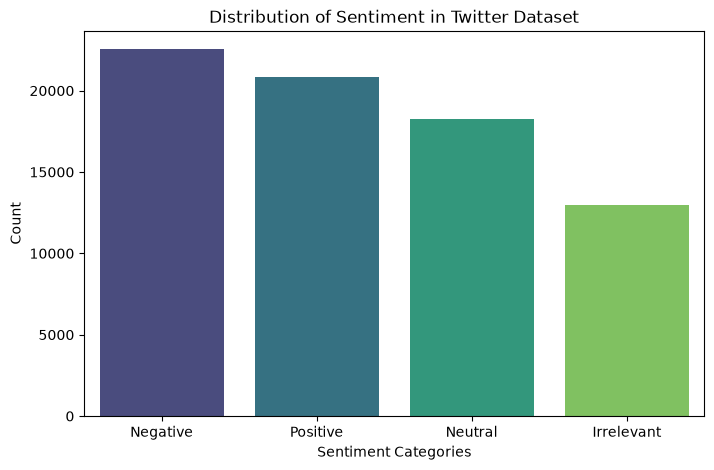

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.countplot(data=df_sentiment, x='Sentiment', palette='viridis', order=df_sentiment['Sentiment'].value_counts().index)
plt.title('Distribution of Sentiment in Twitter Dataset')
plt.xlabel('Sentiment Categories')
plt.ylabel('Count')
plt.show()

### **4. Exploratory Data Visualization**
* **Sentiment Distribution** Visualized the frequency and balance of various sentiment category within the processed Twitter dataset using a Seaborn count plot.
* **Insight:** Highlights the proportional distribution of classes (Irrelevent, Negative, Positive, Neutral) to understand dataset skewness and model perform dynamics.

### **5. Error Analysis & Model Limitations**
* **Class Ambiguity & Overlap:** Categories such as *Negative* and *Neutral* share similar vocabulary and expressions, causing occasional misclassifications by the model and affecting precision-recall trade-offs.
* **Lack of Context & Sarcasm:** Since the Multinomial Naive Bayes model relies purely on word frequencies (TF-IDF), it fails to capture deep contextual nuances, sarcasm, and complex human emotions.
* **Informal Slang & Noise:** Social media text contains heavy abbreviations, misspellings, and informal slang which can introduce noise and limit the model's predictive power.
*

### **6. Conclusion**
* **Baseline Success:** The Multinomial Naive Bayes classifier combined with TF-IDF features successfully established a robust baseline accuracy (~66%) for the Twitter sentiment classification task.
* **End-to-End Pipeline:** Demonstrated a complete Natural Language Processing (NLP) pipeline—from raw data cleaning and transformation to model training and evaluation.
* **Future Scope:** Performance can be further enhanced in future iterations by exploring advanced algorithms, hyperparameter tuning, or contextual transformer models like BERT.